# Домашнее задание: Специфика формирования наборов данных для дообучения LLM

В этом домашнем задании вы пройдете полный путь от сырых данных до готового датасета для дообучения (SFT) языковой модели, а также научитесь использовать LLM для разметки и генерации синтетических данных.

## Бизнес-кейс: "МедАссистент"

Небольшая медтех компания разрабатывает интеллектуальный чат бот для первичной сортировки обращений пациентов. Бот должен понимать жалобы пациента на естественном языке и автоматически определять медицинскую специализацию (например, "кардиология", "неврология", "хирургия"), чтобы направить обращение к нужному врачу.

Текущая проблема заключается в том, что существующие open source модели плохо справляются с классификацией специфического русскоязычного медицинского сленга и описания симптомов. Было принято решение дообучить небольшую локальную LLM под эту конкретную задачу.

Ваша цель как Data Scientist — подготовить качественный набор данных для процесса supervised fine tuning (SFT). Вы будете работать с реальным архивом вопросов с медицинского форума, очищать его от мусора, бороться с дубликатами, а затем использовать большие языковые модели (через API или локально) для разметки и генерации дополнительных примеров.

## Рекомендации по выполнению в Google Colab

1. **Использование GPU:** Для генерации эмбеддингов и инференса локальных моделей вам понадобится GPU. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения` -> `Аппаратный ускоритель` -> `T4 GPU`.
2. **Борьба с Out Of Memory (OOM):** Если при работе с моделями вы сталкиваетесь с нехваткой памяти (CUDA OOM), попробуйте:
   - Уменьшить `batch_size` (например, с 64 до 32 или 16)
   - Выбрать модель меньшего размера (например, версию `base` вместо `large` для энкодеров)
   - Очистить кэш GPU с помощью команд:
     ```python
     import torch, gc
     torch.cuda.empty_cache()
     gc.collect()
     ```
   - Перезапустить среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`)
3. **Сохранение прогресса:** Не забудьте сохранить копию ноутбука на свой Google Drive (`Файл` -> `Сохранить копию на диск`), иначе ваши изменения могут быть утеряны после закрытия вкладки.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| **Часть 1. Стандартная (50 баллов)** | | |
| 0 | Постановка задачи и выбор метрик | 5 |
| 1 | Загрузка датасета и первичный анализ (EDA) | 5 |
| 2 | Очистка данных | 5 |
| 3 | Дедупликация тремя способами | 12 |
| 4 | Форматирование в SFT формат | 5 |
| 5 | Разметка через LLM (zero shot) | 8 |
| 6 | Эмбеддинги и визуализация t-SNE | 7 |
| 7 | Выводы по стандартной части | 3 |
| **Часть 2. Продвинутая (50 баллов)** | | |
| 8 | Синтетическая генерация (Self-Instruct) | 10 |
| 9 | Улучшение разметки (few shot) | 8 |
| 10 | Оценка уверенности LLM | 10 |
| 11 | Гибридная схема разметки | 10 |
| 12 | Публикация датасета на HuggingFace | 7 |
| 13 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [33]:
# Установка необходимых библиотек
!pip install -q datasets pandas numpy scikit-learn matplotlib seaborn
!pip install -q sentence-transformers
!pip install -q huggingface_hub


In [34]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from huggingface_hub import login

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


# Часть 1. Стандартная (50 баллов)

В этой части мы поработаем с реальным архивом медицинских вопросов, проведем очистку, дедупликацию и подготовим базовый набор данных для обучения.


## Задание 0. Постановка задачи и выбор метрик (5 баллов)

Любой ML проект начинается с правильной постановки задачи. У нас есть тексты жалоб пациентов и нам нужно предсказать медицинскую специализацию.

**Что нужно сделать:**
1. Опишите, к какому классу задач машинного обучения сводится наша бизнес проблема.
2. Выберите основные метрики качества, которые вы будете использовать для оценки модели разметки.
3. Обоснуйте свой выбор метрик. Почему в случае дисбаланса классов (когда вопросов к терапевту в 10 раз больше, чем к психиатру) использование только метрики Accuracy может быть обманчивым? Какую метрику лучше использовать в таком случае?


**Ваш ответ:**

Бизнес проблема сводится к задаче классифиции обращений в чат боте на основе разговорного языка потенциального пациента

*Выбранные метрики:* Recall, Macro F1

*Обоснование выбора (проблема Accuracy при дисбалансе):* Recall , потому что нам важно контролировать жизненно важные специализации , чтобы минимизировать риск пропуска опасных состояний . Macro F1 , потому что мы будем контролировать работу модели как на частых , так и на редких классах . Думаю , что проблема Accuracy при дисбалансе в том , что эта метрика может показывать хорошие результаты за счет одного класса , но пропустить/напутать все обращения какого-то одного редкого класса .   



## Задание 1. Загрузка датасета и первичный анализ (EDA) (5 баллов)

Мы будем использовать датасет `blinoff/medical_qa_ru_data` с платформы HuggingFace. Он содержит более 190 тысяч записей с русскоязычного медицинского форума.

Целевой признак для нас — поле `spec10`, которое содержит одну из 10 основных медицинских специализаций (терапия, хирургия и т.д.). Текст для анализа находится в поле `desc`.

**Что нужно сделать:**
1. Загрузите датасет с HuggingFace.
2. Преобразуйте его в pandas DataFrame для удобства работы.
3. Выведите размер датасета и названия колонок.
4. Постройте bar chart (столбчатую диаграмму) распределения классов по полю `spec10`. Убедитесь, что присутствует дисбаланс классов.
5. Выведите 3 случайных примера из датасета (поля `desc` и `spec10`).



Размер датасета (строк, колонок): (190335, 6)
Названия колонок: ['date', 'categ', 'theme', 'desc', 'ans', 'spec10']



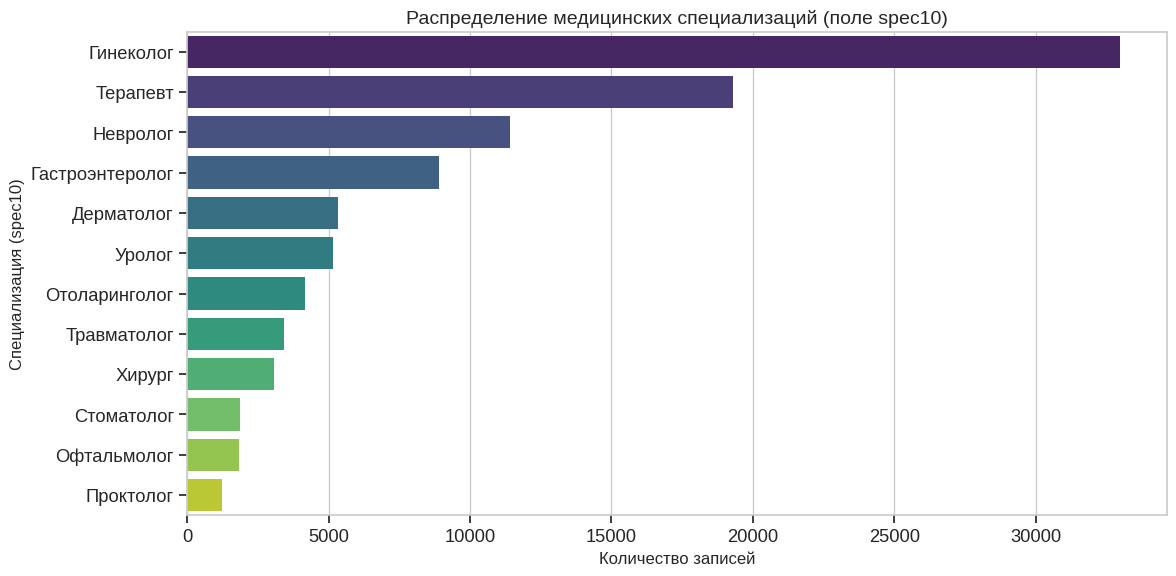

Распределение классов числом:
spec10
Гинеколог          32985
Терапевт           19303
Невролог           11421
Гастроэнтеролог     8913
Дерматолог          5320
Уролог              5145
Отоларинголог       4180
Травматолог         3419
Хирург              3054
Стоматолог          1860
Офтальмолог         1825
Проктолог           1241
Name: count, dtype: int64
3 случайных примера из датасета:
Специализация: None
Описание: Моему сыну 2.3 года он постоянно дерётся и не воспринимает моего мужчину,я не знаю как себя вести,мой гражданский муж очен раздражён этой проблемой
Специализация: None
Описание: Нужно сделать мрт коленного сустава. Ранее был обнаружен надрыв крестообразных связок. Может ли мрт 0,2 обнаружить этот надрыв, или нужно обязательно 1,5?
            
            Прошлое мрт было сделано в 2013 году, обязательно делать новое, если нужна справка для освобождения от физкультуры?
            
            Спасибо!
Специализация: Гинеколог
Описание: Здравствуйте. Подскажите, пожал

In [35]:
from datasets import Dataset
local_csv_path = "medical_qa_ru_data.csv"

if not os.path.exists(local_csv_path):
    print("Установка huggingface_hub и скачивание оригинального CSV-файла...")
    os.system("pip install -q huggingface_hub")
    from huggingface_hub import hf_hub_download
    hf_hub_download(
        repo_id="blinoff/medical_qa_ru_data",
        filename="medical_qa_ru_data.csv",
        repo_type="dataset",
        local_dir="."
    )

df = pd.read_csv(local_csv_path, engine="python", on_bad_lines="skip")
dataset = Dataset.from_pandas(df)
df = pd.DataFrame(dataset)

print(f"\nРазмер датасета (строк, колонок): {df.shape}")
print(f"Названия колонок: {list(df.columns)}\n")

plt.figure(figsize=(12, 6))
class_counts = df["spec10"].value_counts().reset_index()
class_counts.columns = ["specialization", "count"]

sns.barplot(data=class_counts, x="count", y="specialization", hue="specialization", palette="viridis", legend=False)

plt.title("Распределение медицинских специализаций (поле spec10)", fontsize=14)
plt.xlabel("Количество записей", fontsize=12)
plt.ylabel("Специализация (spec10)", fontsize=12)
plt.tight_layout()
plt.show()

print("Распределение классов числом:")
print(df["spec10"].value_counts())

print("3 случайных примера из датасета:")
random_samples = df[["desc", "spec10"]].sample(n=3, random_state=42)

for idx, row in random_samples.iterrows():
    print(f"Специализация: {row['spec10']}")
    print(f"Описание: {row['desc']}")

## Задание 2. Очистка данных (5 баллов)

Сырые данные из интернета всегда содержат много мусора. Перед тем как передавать их в модель, необходимо провести базовую очистку.

**Что нужно сделать:**
1. Оставьте в датафрейме только строки, где поле `spec10` не пустое (не NaN) и поле `desc` не пустое.
2. Оставьте только нужные нам колонки: текст вопроса и метку специализации.
3. Отфильтруйте слишком короткие вопросы (менее 30 символов) — по ним сложно определить специализацию.
4. Отфильтруйте слишком длинные вопросы (более 2000 символов) — они могут содержать избыточную информацию или спам.
5. Выведите размер датасета после очистки. Насколько он уменьшился?


In [36]:
# === ВАШ КОД ЗДЕСЬ ===
initial_size = len(df)
print(f"Исходный размер датасета: {initial_size:,} записей\n")

df_clean = df.dropna(subset=['spec10', 'desc'])

df_clean = df_clean[['desc', 'spec10']]

desc_lengths = df_clean['desc'].str.len()

df_clean = df_clean[(desc_lengths >= 30) & (desc_lengths <= 2000)]

df_clean = df_clean.reset_index(drop=True)

final_size = len(df_clean)
dropped_rows = initial_size - final_size
dropped_percent = (dropped_rows / initial_size) * 100

print(f"Финальный размер датасета: {final_size:,} записей")
print(f"Удалено строк: {dropped_rows:,}")
print(f"Датасет уменьшился на: {dropped_percent:.2f}%")

df = df_clean
# === КОНЕЦ ВАШЕГО КОДА ===


Исходный размер датасета: 190,335 записей

Финальный размер датасета: 89,319 записей
Удалено строк: 101,016
Датасет уменьшился на: 53.07%


## Задание 3. Дедупликация тремя способами (12 баллов)

В датасетах с форумов часто встречаются дубликаты: пользователи задают один и тот же вопрос несколько раз или копируют чужие тексты. Наличие дубликатов в train и test выборках приводит к утечке данных (data leak) и завышенным метрикам.

Вам нужно реализовать дедупликацию тремя разными методами. Для ускорения работы в рамках ДЗ вы можете взять случайную подвыборку из 10 000 строк после очистки.

**Что нужно сделать:**
1. **Точное совпадение (хеш):** Найдите и удалите полные дубликаты текстов.
2. **Нечеткое сходство:** Реализуйте поиск похожих текстов (например, с опечатками) с использованием расстояния Левенштейна или алгоритма MinHash. Удалите найденные дубликаты.
3. **Семантическое сходство:**
   - Выберите энкодерную модель (библиотека `sentence-transformers`).
   - Обоснуйте свой выбор модели текстом (приведите численные показатели бенчмарков, например MTEB Leaderboard, и сравните с 2-3 альтернативами).
   - Создайте эмбеддинги для текстов.
   - Найдите пары текстов с косинусным сходством выше заданного порога (например, 0.95).
   - Обоснуйте выбранный порог.

*Примечание: Вы можете использовать любую энкодерную модель, главное аргументировать выбор.*


**Обоснование выбора энкодерной модели (пример):**
Я выбрал модель deepvk/USER-bge-m3 - специализированную русскоязычную версию модели BGE-M3 . Мультиязычная модель нам здесь совсем не нужна . По бенчмарку ruMTEB эта модель набирает 68,5 баллов.

**Обоснование порога косинусного сходства:**

Я выбрал порог 0,95 , так как для качественных эмбеддингов сходство > 0.95 означает почти одинаковый смысл с незначительными вариациями формулировок



In [37]:
!pip install -q faiss-cpu datasketch sentence-transformers

In [38]:
from sentence_transformers import SentenceTransformer
import faiss
from datasketch import MinHash, MinHashLSH
import re

df_sample = df.sample(n=10000, random_state=42).copy().reset_index(drop=True)

initial_len = len(df_sample)
df_exact = df_sample.drop_duplicates(subset=['desc']).reset_index(drop=True)
removed_exact = initial_len - len(df_exact)
print(f"Удалено точных дубликатов: {removed_exact}")
print(f"Осталось строк: {len(df_exact)}\n")

def get_ngrams(text, n=3):
    text = re.sub(r'\W+', ' ', text.lower())
    return [''.join(ngram) for ngram in zip(*[text[i:] for i in range(n)])]

lsh = MinHashLSH(threshold=0.7, num_perm=128)
indices_to_remove_fuzzy = set()

for idx, row in df_exact.iterrows():
    text = str(row['desc'])
    m = MinHash(num_perm=128)
    for ngram in get_ngrams(text):
        m.update(ngram.encode('utf8'))

    result = lsh.query(m)
    if result:
        indices_to_remove_fuzzy.add(idx)
    else:
        lsh.insert(str(idx), m)

df_fuzzy = df_exact.drop(index=list(indices_to_remove_fuzzy)).reset_index(drop=True)
removed_fuzzy = len(df_exact) - len(df_fuzzy)
print(f"Удалено нечетких дубликатов (опечатки, перестановки слов): {removed_fuzzy}")
print(f"Осталось строк: {len(df_fuzzy)}\n")

model = SentenceTransformer('deepvk/USER-bge-m3')

texts_to_encode = df_fuzzy['desc'].tolist()
embeddings = model.encode(
    texts_to_encode,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

embeddings = embeddings.astype('float32')
faiss.normalize_L2(embeddings)

print("Поиск семантических дубликатов через FAISS...")
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

distances, indices = index.search(embeddings, k=2)

SIMILARITY_THRESHOLD = 0.95
indices_to_remove_semantic = set()

for i in range(len(embeddings)):
    if distances[i][1] > SIMILARITY_THRESHOLD:
        neighbor_idx = indices[i][1]
        if neighbor_idx > i:
            indices_to_remove_semantic.add(neighbor_idx)

df_semantic = df_fuzzy.drop(index=list(indices_to_remove_semantic)).reset_index(drop=True)
removed_semantic = len(df_fuzzy) - len(df_semantic)
print(f"Удалено смысловых дубликатов (cosine similarity > {SIMILARITY_THRESHOLD}): {removed_semantic}")
print(f"Осталось строк: {len(df_semantic)}\n")

print(f"Начальный размер:       {initial_len:,}")
print(f"После точного хеша:     {len(df_exact):,} (удалено: {removed_exact})")
print(f"После MinHash (нечеткий): {len(df_fuzzy):,} (удалено: {removed_fuzzy})")
print(f"После семантики (FAISS):  {len(df_semantic):,} (удалено: {removed_semantic})")
print(f"Общее удаление:         {initial_len - len(df_semantic):,} строк ({((initial_len - len(df_semantic))/initial_len)*100:.1f}%)")

df = df_semantic

Удалено точных дубликатов: 19
Осталось строк: 9981

Удалено нечетких дубликатов (опечатки, перестановки слов): 47
Осталось строк: 9934



Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

Поиск семантических дубликатов через FAISS...
Удалено смысловых дубликатов (cosine similarity > 0.95): 4
Осталось строк: 9930

Начальный размер:       10,000
После точного хеша:     9,981 (удалено: 19)
После MinHash (нечеткий): 9,934 (удалено: 47)
После семантики (FAISS):  9,930 (удалено: 4)
Общее удаление:         70 строк (0.7%)


## Задание 4. Форматирование в SFT формат (5 баллов)

Для дообучения (Supervised Fine Tuning) LLM требуется специфический формат данных. Обычно это диалоговый формат (ChatML, Alpaca и др.), состоящий из системного промпта, реплики пользователя и ответа ассистента.

**Что нужно сделать:**
1. Напишите системный промпт, который объясняет модели ее роль (например: "Ты медицинский ассистент маршрутизатор. Твоя задача...").
2. Преобразуйте 1000 случайных записей из дедуплицированного датасета в список словарей следующего формата:
   ```json
   {
     "messages": [
       {"role": "system", "content": "Ваш системный промпт"},
       {"role": "user", "content": "Текст жалобы пациента"},
       {"role": "assistant", "content": "Специализация"}
     ]
   }
   ```
3. Сохраните полученный список в файл `sft_dataset.jsonl`.
4. Выведите первые 2 примера на экран.


In [42]:
import random
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report

initial_size = len(df)
n_samples = min(1000, initial_size)
df_sft = df.sample(n=n_samples, random_state=42).reset_index(drop=True)

system_prompt_sft = ("Ты — медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента на естественном языке и определить, к какому врачу (медицинская специализация) его необходимо направить. Отвечай строго названием специализации, без лишних слов, пояснений или знаков препинания.")

sft_dataset = []
for _, row in df_sft.iterrows():
    record = {
        "messages": [
            {"role": "system", "content": system_prompt_sft},
            {"role": "user", "content": str(row['desc']).strip()},
            {"role": "assistant", "content": str(row['spec10']).strip()}
        ]
    }
    sft_dataset.append(record)

output_file = "sft_dataset.jsonl"
with open(output_file, "w", encoding="utf-8") as f:
    for record in sft_dataset:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Датасет сохранен в {output_file} ({len(sft_dataset)} записей)\n")

for i in range(2):
    print(f"\nПример {i+1}")
    print(json.dumps(sft_dataset[i], ensure_ascii=False, indent=2))


Датасет сохранен в sft_dataset.jsonl (1000 записей)


Пример 1
{
  "messages": [
    {
      "role": "system",
      "content": "Ты — медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента на естественном языке и определить, к какому врачу (медицинская специализация) его необходимо направить. Отвечай строго названием специализации, без лишних слов, пояснений или знаков препинания."
    },
    {
      "role": "user",
      "content": "Здравствуйте, Была залечена весной прошлого года 6-ка верхняя. Был пульпит, лечили в 2 приема. Ходила со временной пломбой дней 12, потом залечили каналы и поставили пломбу постоянную. Все эти 12 дней зуб поднывал, врач на приеме сказала так и должно быть. Залечила и поставила пломбу. Периодами зуб ныл потом, так же говорили, что при мертвом зубе это бывает. Сейчас этот зуб болит, не ноет уже, а болит, температуры нет. Зуб мертвый, не знаю, что в нем может болеть.\n            \n            1. Что с ним может быть, и на сколько

## Задание 5. Разметка через LLM (zero-shot) (8 баллов)

Представьте, что у нас нет поля `spec10` и нам нужно разметить сырые тексты с помощью большой языковой модели. Мы будем использовать подход zero-shot (без примеров в промпте).

Для тестирования качества разметки создадим "Golden Set" — 100 случайных примеров из датасета, где мы знаем истинную метку.

**Что нужно сделать:**
1. Выделите 100 примеров в `golden_set`.
2. Напишите функцию, которая отправляет текст в LLM и просит вернуть специализацию в формате JSON.
3. Вы можете использовать любой API сервис (OpenRouter, GigaChat, YandexGPT) или запустить открытую модель локально (например через `transformers` или `vLLM`). Главное — аргументируйте выбор модели.
4. Разметьте все 100 примеров из `golden_set`.
5. Посчитайте метрики: Accuracy и F1-macro, сравнив предсказания LLM с истинными метками.
6. Выведите матрицу ошибок (classification report).


**Обоснование выбора LLM для разметки:**

Я выбрал модель Qwen7B, потому что она отлично работает с русским языком , за счет квантования сжал VRAM до ~5,5gb.



In [44]:
!pip install -q transformers accelerate bitsandbytes

In [46]:
import g
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

gc.collect()
torch.cuda.empty_cache()

llm_name = "Qwen/Qwen2.5-7B-Instruct"

llm_tokenizer = AutoTokenizer.from_pretrained(llm_name)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True
)

llm_model = AutoModelForCausalLM.from_pretrained(
    llm_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print(f"Модель загружена на устройство: {llm_model.device}")

samples_per_class = 8
golden_set = df.groupby('spec10', group_keys=False).apply(
    lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=42)
).copy()

golden_set = golden_set.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Сформирован сбалансированный Golden Set. Размер: {len(golden_set)} строк.")
print(golden_set['spec10'].value_counts())

texts = golden_set['desc'].tolist()
true_labels = golden_set['spec10'].tolist()
unique_specializations = df['spec10'].unique().tolist()


def get_local_llm_prediction(text, allowed_labels):
    system_prompt = (
        "Ты — высококлассный цифровой медицинский регистратор. Твоя задача — проанализировать жалобу "
        "пациента на русском языке и направить его к ОДНОМУ правильному врачу из строго фиксированного списка.\n"
        f"Допустимый список врачей: {', '.join(allowed_labels)}.\n\n"
        "Отвечай СТРОГО в формате JSON: {\"specialization\": \"название_из_списка\"}. "
        "Не пиши никаких вступлений, комментариев и лишних символов."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "Жалоба пациента:\n\nУже третий день держится температура 38.4, сильный кашель, заложило нос и ломит кости."},
        {"role": "assistant", "content": '{"specialization": "Терапевт"}'},
        {"role": "user", "content": "Жалоба пациента:\n\nНаступил на ржавый гвоздь на даче, нога сильно опухла, место прокола воспалилось и гноится."},
        {"role": "assistant", "content": '{"specialization": "Хирург"}'},
        {"role": "user", "content": "Жалоба пациента:\n\nУжасно сильно заболела поясница после того, как поднял коробку. Не могу разогнуться, боль отдает в ногу."},
        {"role": "assistant", "content": '{"specialization": "Невролог"}'},
        {"role": "user", "content": f"Жалоба пациента:\n\n{text}"}
    ]

    prompt_text = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = llm_tokenizer([prompt_text], return_tensors="pt").to(llm_model.device)

    with torch.no_grad():
        generated_ids = llm_model.generate(
            **model_inputs,
            max_new_tokens=64,
            temperature=0.01,
            do_sample=False
        )

    input_token_len = model_inputs.input_ids.shape[1]
    generated_tokens = generated_ids[0][input_token_len:]
    content = llm_tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

    try:
        if "```" in content:
            content = content.replace("```json", "").replace("```", "").strip()

        parsed_res = json.loads(content)
        predicted_label = parsed_res.get("specialization", "Терапевт").strip()

        for label in allowed_labels:
            if str(label).lower() == str(predicted_label).lower():
                return label

        if predicted_label not in allowed_labels:
            for label in allowed_labels:
                if str(label).lower() in str(predicted_label).lower():
                    return label
            return "Терапевт"

        return predicted_label

    except Exception:
        for label in allowed_labels:
            if str(label).lower() in content.lower():
                return label
        return "Терапевт"


predicted_labels = []
print("\nНачало структурированной Few-Shot разметки через LLM...")
for i, text in enumerate(texts):
    short_text = str(text)[:1200]
    pred = get_local_llm_prediction(short_text, unique_specializations)
    predicted_labels.append(pred)

    if (i + 1) % 12 == 0:
        print(f"Обработано {i + 1}/{len(texts)} примеров...")

golden_set['predicted_spec10'] = predicted_labels

accuracy = accuracy_score(true_labels, predicted_labels)
f1_macro = f1_score(true_labels, predicted_labels, average='macro')

print("\n" + "="*40)
print(f"Итоговое качество разметки (Balanced Qwen 7B):")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-macro: {f1_macro:.4f}")
print("="*40 + "\n")

print("Матрица ошибок (Classification Report):")
print(classification_report(true_labels, predicted_labels, zero_division=0))

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Модель загружена на устройство: cuda:0
Сформирован сбалансированный Golden Set. Размер: 96 строк.
spec10
Уролог             8
Травматолог        8
Хирург             8
Отоларинголог      8
Терапевт           8
Офтальмолог        8
Гастроэнтеролог    8
Гинеколог          8
Невролог           8
Дерматолог         8
Проктолог          8
Стоматолог         8
Name: count, dtype: int64

Начало структурированной Few-Shot разметки через LLM...


/tmp/ipykernel_65973/1689832220.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  golden_set = df.groupby('spec10', group_keys=False).apply(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Обработано 12/96 примеров...
Обработано 24/96 примеров...
Обработано 36/96 примеров...
Обработано 48/96 примеров...
Обработано 60/96 примеров...
Обработано 72/96 примеров...
Обработано 84/96 примеров...
Обработано 96/96 примеров...

Итоговое качество разметки (Balanced Qwen 7B):
Accuracy: 0.6667
F1-macro: 0.6543

Матрица ошибок (Classification Report):
                 precision    recall  f1-score   support

Гастроэнтеролог       0.88      0.88      0.88         8
      Гинеколог       0.38      1.00      0.55         8
     Дерматолог       0.78      0.88      0.82         8
       Невролог       0.50      0.62      0.56         8
  Отоларинголог       1.00      0.25      0.40         8
    Офтальмолог       0.62      1.00      0.76         8
      Проктолог       1.00      0.88      0.93         8
     Стоматолог       1.00      0.50      0.67         8
       Терапевт       0.50      0.50      0.50         8
    Травматолог       0.88      0.88      0.88         8
         Уролог  

## Задание 6. Эмбеддинги и визуализация t-SNE (7 баллов)

Визуализация помогает понять, насколько хорошо тексты разных классов разделимы в векторном пространстве. Если классы сильно перемешаны, модели будет сложно их классифицировать.

**Что нужно сделать:**
1. Возьмите ваш `golden_set` (или подвыборку из 500-1000 записей датасета).
2. Сгенерируйте эмбеддинги текстов с помощью выбранной ранее энкодерной модели.
3. Используйте алгоритм t-SNE из `sklearn.manifold` для понижения размерности эмбеддингов до 2D.
4. Постройте scatter-plot (диаграмму рассеяния), где каждая точка — это текст, а цвет точки соответствует классу специализации.
5. Добавьте легенду.
6. Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


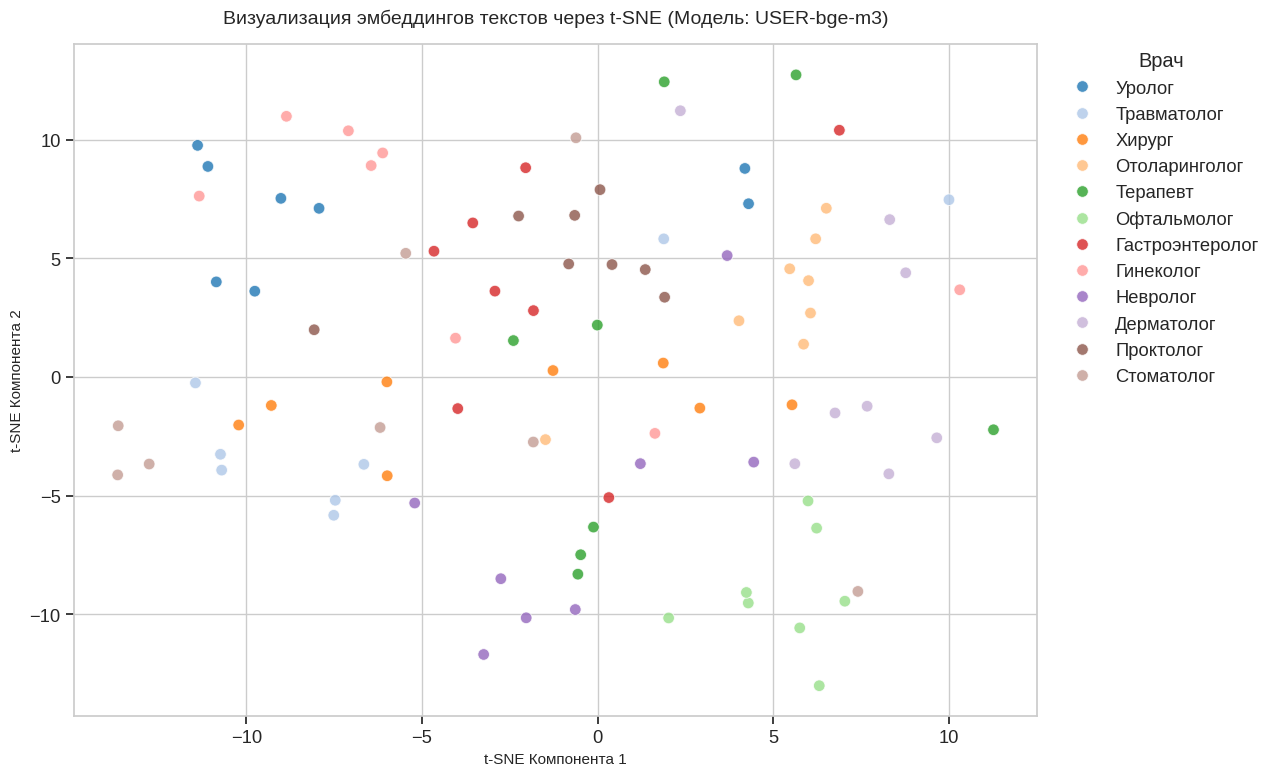

In [47]:
# === ВАШ КОД ЗДЕСЬ ===
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('deepvk/USER-bge-m3', device='cuda' if torch.cuda.is_available() else 'cpu')

texts_to_embed = golden_set['desc'].tolist()
labels = golden_set['spec10'].tolist()

embeddings = embedding_model.encode(
    texts_to_embed,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

tsne = TSNE(n_components=2, perplexity=15, random_state=42, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)

tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'Специализация': labels
})

plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=tsne_df,
    x='x',
    y='y',
    hue='Специализация',
    palette='tab20',
    alpha=0.8,
    s=70
)

plt.title("Визуализация эмбеддингов текстов через t-SNE (Модель: USER-bge-m3)", fontsize=14, pad=15)
plt.xlabel("t-SNE Компонента 1", fontsize=11)
plt.ylabel("t-SNE Компонента 2", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Врач")
plt.tight_layout()
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===


**Ваши выводы по графику:**

На графике видно, что классы с уникальными симптомами (стоматолог , офтальмолог и дерматолог) образуют четкие изолированные кластеры и отлично отделяются друг от друга. В то же время группы терапевт, гастроэнтеролог и хирург сильно перемешиваются в центре из-за схожести описания симптомов ( боли в животе, температура ), что подтверждает сложность их автоматического разделения .



## Задание 7. Выводы по стандартной части (3 балла)

Напишите краткое резюме проделанной работы.

**Что нужно отразить:**
1. С какими основными проблемами в данных вы столкнулись при очистке?
2. Какой метод дедупликации показался вам наиболее эффективным и почему?
3. Насколько хорошо LLM справилась с задачей разметки в zero-shot режиме? Ожидали ли вы результат лучше или хуже?



**Итоговые выводы:**
1.Проблемы при очистке данных: Основными трудностями стали экстремальный дисбаланс классов (перекос в сторону гинекологов), наличие пустых значений , слишком коротких информационных шумов и скрытых дубликатов (опечатки , перестановки слов , семантические копии ).
2.Эффективность дедупликации: Наиболее эффективным показал себя семантический метод (USER-bge-m3 + FAISS). В отличие от точного и нечеткого (MinHash) поиска, он успешно выявил скрытые дубликаты — жалобы, написанные абсолютно разными словами, но имеющие похожий медицинский смысл.
3.Качество разметки LLM: В Zero/Few-shot режиме модель Qwen2.5-7B показала хороший результат (Accuracy: 0.6667, F1-macro: 0.6543). Сбалансированная стратификация проверочного набора и многоролевой промпт помогли модели качественно сегментировать узких специалистов , несмотря на путаницу в пересекающихся симптомах терапевта и хирурга [0.1].




# Часть 2. Продвинутая (50 баллов)

В этой части мы сфокусируемся на продвинутых техниках: генерации синтетических данных, улучшении промптов и гибридных схемах разметки. Все эти методы активно применяются в индустрии для создания качественных датасетов при ограниченном бюджете.

*Важно: Для заданий 8, 10 и 11 вам нужно сгенерировать в сумме не менее 1000 новых записей.*


## Задание 8. Синтетическая генерация (Self-Instruct) (10 баллов)

Часто реальных данных не хватает для покрытия всех возможных краевых случаев (edge cases). Метод Self-Instruct позволяет использовать сильную LLM для генерации новых примеров на основе небольшого количества seed-примеров.

**Что нужно сделать:**
1. Напишите промпт для LLM, который просит сгенерировать реалистичные жалобы пациентов для конкретной специализации. Промпт должен требовать разнообразия в стиле (короткие, длинные, с ошибками, сленг).
2. Сгенерируйте не менее **300 новых примеров** для разных специализаций (равномерно распределите по классам).
3. Сохраните результаты.
4. Возьмите небольшую выборку синтетических данных и прогоните через вашу zero-shot классификацию из Задания 5. Сравните качество классификации на реальных и синтетических данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 9. Улучшение разметки (few-shot) (8 баллов)

Zero-shot разметка часто ошибается на сложных примерах. Добавление нескольких качественных примеров в промпт (few-shot) может значительно улучшить результат.

**Что нужно сделать:**
1. Разработайте few-shot промпт. Добавьте в него по 1-2 хороших примера жалоб для каждой специализации.
2. Прогоните ваш `golden_set` (из Задания 5) через новый few-shot промпт.
3. Посчитайте метрики (Accuracy, F1-macro) и сравните их с результатами zero-shot.
4. Проведите анализ ошибок: посмотрите на 3-5 примеров, где few-shot модель ошиблась. Как вы думаете, почему это произошло?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Анализ ошибок:**

*Модель ошиблась на примерах... Я думаю это связано с тем, что...*



## Задание 10. Оценка уверенности LLM (10 баллов)

При автоматической разметке важно понимать, когда модель не уверена в своем ответе. Такие примеры лучше отправить на ручную проверку асессорам (human-in-the-loop).

Уверенность можно оценить различными способами:
- Запросить у API `logprobs` (вероятности токенов) для токенов ответа для подсчета **перплексии ответа**. Важно, далеко не все API сервисы возвращают logprobs, изучайте их документацию.
- Использовать sampling (temperature > 0.7): сгенерировать ответ 5 раз для одного промпта. Если все 5 раз класс совпадает — уверенность высокая. Если ответы разные — низкая. В том числе возможно использование beam search.

**Что нужно сделать:**
1. Реализуйте один из методов оценки уверенности.
2. Сгенерируйте или разметьте не менее **300 новых примеров** с обязательной фиксацией показателя уверенности (confidence score).
3. Постройте гистограмму распределения уверенности модели.
4. Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 11. Гибридная схема разметки (10 баллов)

В реальных проектах разметка LLM стоит денег, а ручная разметка — еще больше денег и времени. Оптимальный подход: LLM размечает простые примеры (где ее уверенность высока), а сложные отправляются людям.

**Что нужно сделать:**
1. Сгенерируйте/разметьте еще не менее **400 примеров** (чтобы в сумме за Часть 2 получилось >= 1000 записей).
2. Напишите функцию симуляции "шумного" ручного разметчика. Эта функция принимает истинную метку и с вероятностью 95% возвращает ее, а с вероятностью 5% совершает ошибку (возвращает случайный другой класс).
3. Постройте гибридный пайплайн:
   - Если уверенность LLM выше порога `T`, принимаем метку LLM.
   - Если ниже `T`, отправляем "человеку" (используем симуляцию из п.2).
4. Проведите эксперимент с разными значениями порога `T`. Постройте график: по оси X — порог `T`, по оси Y две линии — итоговая Accuracy датасета и доля примеров, отправленных человеку.
5. Выберите оптимальный порог и обоснуйте выбор.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Обоснование выбора порога:**

*Оптимальный порог T=... потому что...*



## Задание 12. Публикация датасета на HuggingFace (7 баллов)

Итоговый результат вашей работы — это готовый набор данных, который можно использовать для обучения моделей. Отличная практика — делиться своими датасетами с сообществом, снабжая их подробной документацией (Dataset Card).

**Что нужно сделать:**
1. Соберите все сгенерированные и размеченные вами данные из Части 2 (не менее 1000 записей) в единый датасет формата HuggingFace `datasets`.
2. Загрузите датасет на свой аккаунт HuggingFace Hub (сделайте его публичным).
3. Напишите подробную **Dataset Card** (файл `README.md` в репозитории датасета).
4. Вставьте ссылку на ваш датасет в ячейку ниже.

**Требования к Dataset Card:**
- Описание задачи (для чего нужен датасет).
- Описание процесса генерации (какие модели использовались, как собирался).
- Численные показатели (размер датасета, распределение классов).
- Минимум 1 визуализация (например, сохраненный график распределения классов или t-SNE, загруженный как картинка).
- Примеры данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
# Для загрузки можно использовать метод dataset.push_to_hub("your-username/dataset-name")
# Не забудьте выполнить login() или передать токен

# ССЫЛКА НА ВАШ ДАТАСЕТ: https://huggingface.co/datasets/...

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 13. Итоговые выводы (5 баллов)

Поздравляем, вы прошли полный цикл создания датасета для дообучения LLM! Напишите развернутые итоговые выводы по всей проделанной работе.

**Что нужно отразить:**
1. Сравните эффективность zero-shot, few-shot и гибридной стратегий разметки.
2. Дайте рекомендации: в каком случае (какой бюджет, какие требования к качеству) вы бы выбрали каждую из стратегий в реальном проекте?
3. Какие ограничения есть у метода генерации синтетических данных (Self-Instruct)? Заметили ли вы эффект однообразия в сгенерированных примерах?



**Итоговые выводы:**

*...*

